# **Découverte des données**

In [76]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print("- Numpy version:", np.__version__)
print("- matplotlib version :", matplotlib.__version__)
print("- Pandas version:", pd.__version__)

dvf = pd.read_csv('./train_data_accidents.csv')

- Numpy version: 2.0.2
- matplotlib version : 3.10.0
- Pandas version: 2.2.2


In [77]:
dvf.describe()

,place,catu,sexe,trajet,secu1,secu2,secu3,locp,catv,an_nais,...,vosp,prof,plan,surf,infra,situ,lat,long,jour,grav
count,198448.000000,198448.000000,198448.000000,198448.00000,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000,193851.000000,...,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000,198448.000000
mean,1.738244,1.258471,1.260854,3.09925,1.800688,0.973459,-0.928853,-0.407946,12.204779,1983.126324,...,0.198989,1.227510,1.262688,1.254238,0.739070,1.363415,44.372023,2.424952,15.794329,2.455868
std,2.046079,0.521003,0.575758,2.79234,2.157863,3.013339,0.815751,0.962238,12.929179,18.196734,...,0.654632,0.540205,0.643377,0.783651,2.049499,1.269378,11.960855,18.732530,8.790684,1.399174
min,-1.000000,1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1912.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-23.395090,-176.218643,1.000000,-1.000000
25%,1.000000,1.000000,1.000000,0.00000,1.000000,-1.000000,-1.000000,-1.000000,7.000000,1971.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,44.541917,1.418640,8.000000,1.000000
50%,1.000000,1.000000,1.000000,4.00000,1.000000,0.000000,-1.000000,-1.000000,7.000000,1986.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,47.750755,2.403684,16.000000,3.000000
75%,1.000000,1.000000,2.000000,5.00000,2.000000,0.000000,-1.000000,0.000000,10.000000,1998.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,48.858002,4.838890,23.000000,4.000000
max,10.000000,3.000000,2.000000,9.00000,9.000000,9.000000,9.000000,9.000000,99.000000,2021.000000,...,3.000000,4.000000,4.000000,9.000000,9.000000,8.000000,51.057332,168.106549,31.000000,4.000000


On constate tout d'abord que certaines données sont inutilisables à cause de NaN à certains endroits

In [78]:
print(dvf.columns)

Index(['place', 'catu', 'sexe', 'trajet', 'secu1', 'secu2', 'secu3', 'locp',
       'catv', 'an_nais', 'mois', 'occutc', 'obs', 'obsm', 'choc', 'manv',
       'lum', 'agg', 'int', 'atm', 'col', 'catr', 'circ', 'vosp', 'prof',
       'plan', 'surf', 'infra', 'situ', 'lat', 'long', 'hrmn', 'jour', 'grav'],
      dtype='object')


In [79]:
del dvf['hrmn']
dvf.drop(dvf.index[(dvf['grav'] == -1)],axis=0,inplace=True)
dvf.drop(dvf.index[(dvf['an_nais'].isnull())],axis=0,inplace=True)

In [80]:
dvf.describe()

,place,catu,sexe,trajet,secu1,secu2,secu3,locp,catv,an_nais,...,vosp,prof,plan,surf,infra,situ,lat,long,jour,grav
count,193851.000000,193851.000000,193851.000000,193851.000000,193851.000000,193851.000000,193851.000000,193851.000000,193851.000000,193851.000000,...,193851.000000,193851.000000,193851.000000,193851.000000,193851.000000,193851.000000,193851.000000,193851.000000,193851.000000,193851.000000
mean,1.755869,1.264600,1.314329,3.196311,1.841311,1.017457,-0.929926,-0.394313,12.180082,1983.126324,...,0.197074,1.228805,1.264745,1.255712,0.736994,1.361133,44.358010,2.439805,15.784262,2.491135
std,2.066835,0.525604,0.464349,2.752145,2.119434,3.031104,0.810449,0.969005,12.854050,18.196734,...,0.652323,0.542083,0.645742,0.788400,2.045009,1.265332,11.990416,18.829741,8.788369,1.396051
min,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1912.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-23.395090,-176.218643,1.000000,1.000000
25%,1.000000,1.000000,1.000000,0.000000,1.000000,-1.000000,-1.000000,-1.000000,7.000000,1971.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,44.538975,1.398767,8.000000,1.000000
50%,1.000000,1.000000,1.000000,4.000000,1.000000,0.000000,-1.000000,-1.000000,7.000000,1986.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,47.736151,2.403830,16.000000,3.000000
75%,1.000000,1.000000,2.000000,5.000000,2.000000,0.000000,-1.000000,0.000000,10.000000,1998.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,48.856467,4.838937,23.000000,4.000000
max,10.000000,3.000000,2.000000,9.000000,9.000000,9.000000,9.000000,9.000000,99.000000,2021.000000,...,3.000000,4.000000,4.000000,9.000000,9.000000,8.000000,51.057332,168.106549,31.000000,4.000000


In [116]:
dvf['choc'].loc[dvf['occutc'] == 0].describe()

,choc
count,1.0
mean,7.0
std,NaN
min,7.0
25%,7.0
50%,7.0
75%,7.0
max,7.0


Voici la heatmap des corrélations entre données

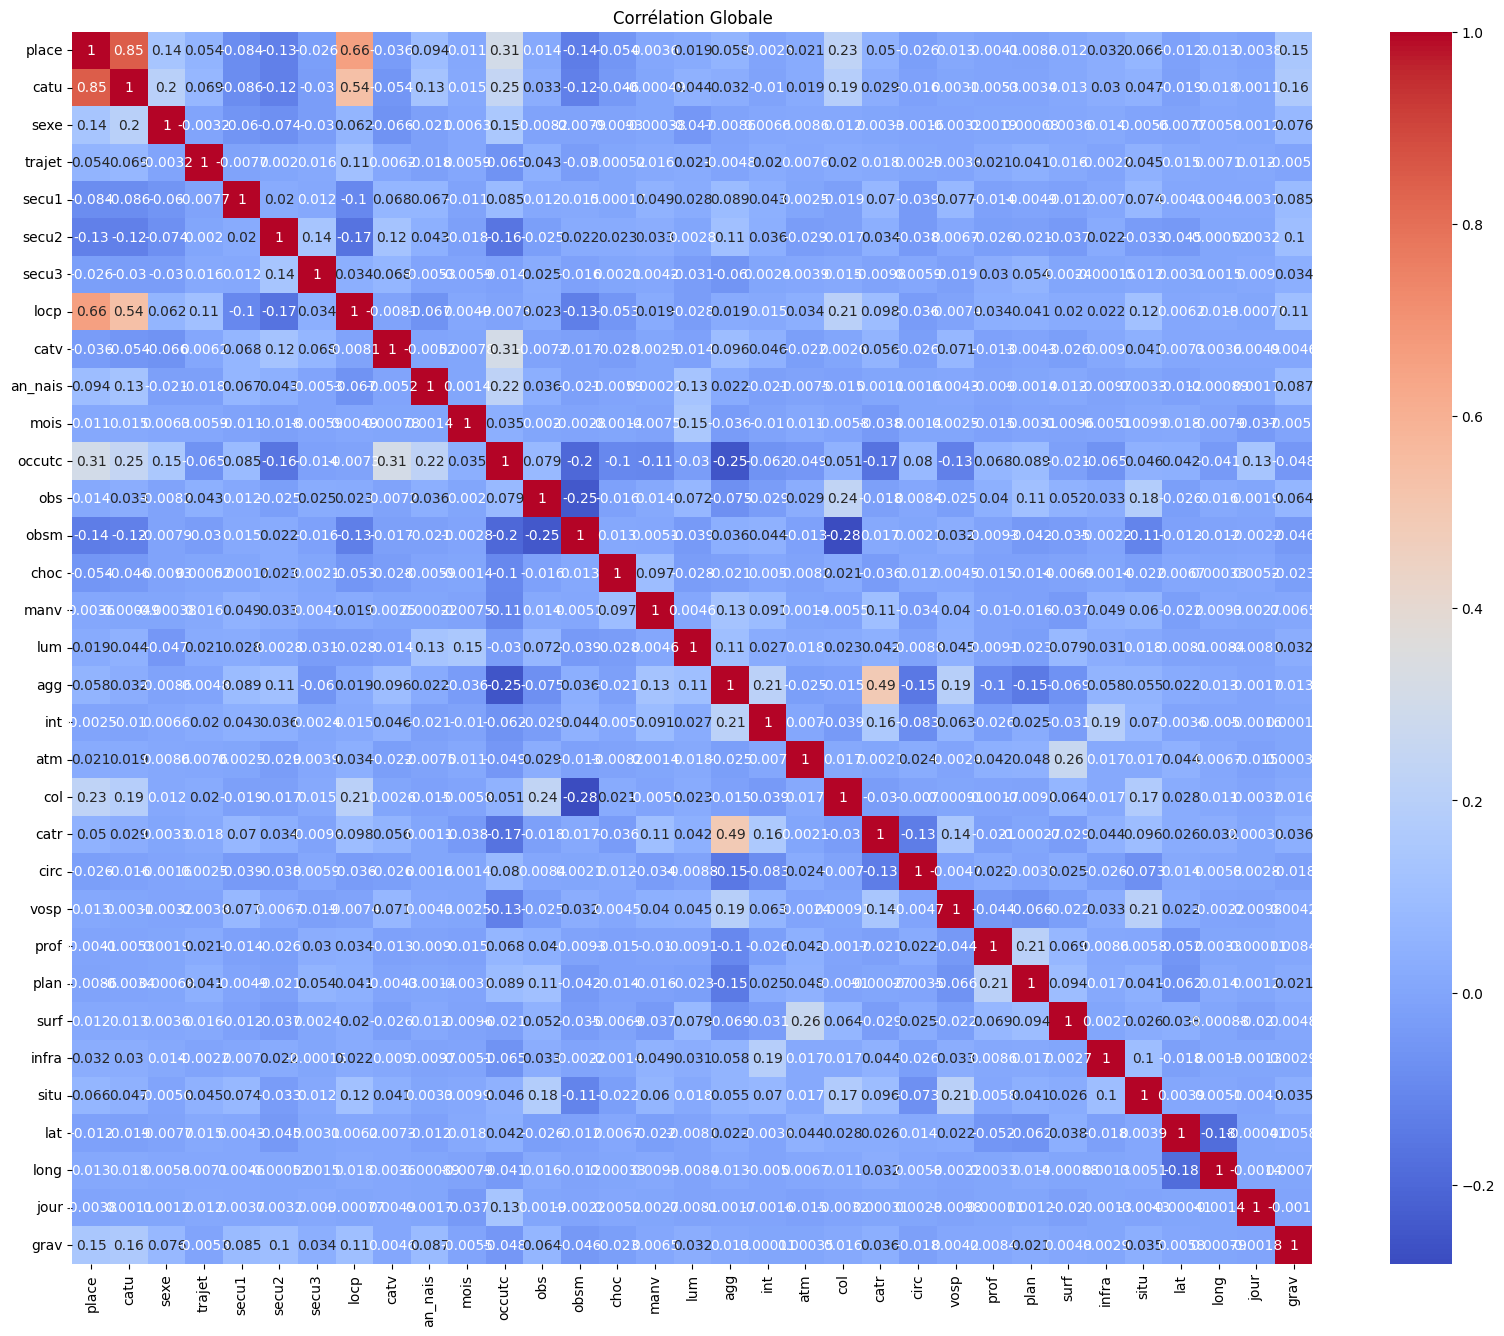

In [84]:
plt.figure(figsize=(20, 16))
sns.heatmap(dvf.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Corrélation Globale")
plt.show()